## Implement Boston housing price prediction problem by Linear
## regression using Deep Neural network.
## Use Boston House price prediction dataset.

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
# using keras dataset
# (X_train, y_train), (X_test, y_test) = keras.datasets.boston_housing.load_data()

# # #convert it to dataframe
# df = pd.DataFrame(X_train)
# df['target'] = pd.DataFrame(y_train)
# df.head()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,0,1,2,3,4,5,6,7,8,9,10,11,12,target
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


In [ ]:
df = pd.read_csv('HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
df = df.fillna(df.mean())
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
from sklearn.model_selection import train_test_split

#split features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

(X_train, X_test, y_train, y_test) = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#normalize, feature scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

#build the nueral network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # by default activation is linear
])

# # MSE loss for regression; MAE as human-readable metric
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# validation is used for evaluation after each epoch - used to detect overfitting, early stopping
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 601.1749 - mae: 22.5967 - val_loss: 520.7935 - val_mae: 21.2838
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 556.2438 - mae: 21.6229 - val_loss: 475.8321 - val_mae: 20.2532
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 501.5580 - mae: 20.3907 - val_loss: 416.2940 - val_mae: 18.8142
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 428.9504 - mae: 18.6347 - val_loss: 337.1995 - val_mae: 16.7431
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 335.2794 - mae: 16.2168 - val_loss: 243.6154 - val_mae: 14.0221
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 229.4536 - mae: 13.1232 - val_loss: 147.8369 - val_mae: 10.7171
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 131.5944 - mae: 9.4782 - val_loss: 74.7484 - val_mae: 7.1402
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 73.4340 - mae: 6.9070 - val_loss: 41.6713 - val_mae: 4.7583
Epoch 9/100
11/11 ━━━━

In [ ]:

# # ----- 6. Plot Training Curves -----
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.plot(history.history['loss'],     label='Train MSE')
# ax1.plot(history.history['val_loss'], label='Val MSE')
# ax1.set_title('Loss (MSE)'); ax1.set_xlabel('Epoch'); ax1.legend()

# ax2.plot(history.history['mae'],     label='Train MAE')
# ax2.plot(history.history['val_mae'], label='Val MAE')
# ax2.set_title('Mean Absolute Error'); ax2.set_xlabel('Epoch'); ax2.legend()

# plt.tight_layout()
# plt.show()

# # ----- 7. Sample Predictions -----
# predictions = model.predict(X_test[:5]).flatten()
# for i in range(5):
#     print(f"Predicted: ${predictions[i]*1000:.0f}  |  Actual: ${y_test[i]*1000:.0f}")

In [ ]:
#evaluate
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
rmse = np.sqrt(test_loss)
print(f"\nTest MSE  : {test_loss:.2f}")
print(f"Test MAE  : {test_mae:.2f}  (avg error ≈ ${test_mae*1000:.0f})")



Test MSE  : 13.49
Test MAE  : 2.42  (avg error ≈ $2424)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


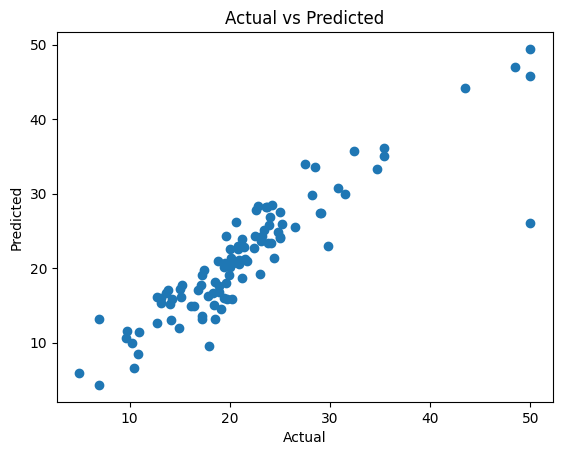

In [ ]:
#plot graph
# Predictions
y_pred = model.predict(X_test)
# Scatter Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# ----- 7. Sample Predictions -----
predictions = model.predict(X_test[:5]).flatten()
for i in range(5):
    print(f"Predicted: ${predictions[i]*1000:.0f}  |  Actual: ${y_test.iloc[i]*1000:.0f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: $28215  |  Actual: $23600
Predicted: $35760  |  Actual: $32400
Predicted: $16736  |  Actual: $13600
Predicted: $28401  |  Actual: $22800
Predicted: $14892  |  Actual: $16100


# Neeraj practice

In [1]:
!pip install tensorflow

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [9]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [10]:
df = df.fillna(df.mean())
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [19]:
#find X and y , x will be my features and y will be the target variable
X = df.drop('MEDV',axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
#normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [24]:
model = keras.Sequential([
    layers.Dense(64,activation="relu",input_shape=(X_train.shape[1],)),
    layers.Dense(64,activation="relu"),
    layers.Dense(1)
])

In [27]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 585.6725 - mae: 22.2396 - val_loss: 504.4771 - val_mae: 20.8831
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 538.1658 - mae: 21.1667 - val_loss: 455.2629 - val_mae: 19.7071
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 476.0700 - mae: 19.7196 - val_loss: 389.6390 - val_mae: 18.0543
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 396.1680 - mae: 17.7111 - val_loss: 304.1640 - val_mae: 15.6962
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 298.7212 - mae: 14.9466 - val_loss: 210.3489 - val_mae: 12.7293
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 205.8789 - mae: 11.8984 - val_loss: 131.1518 - val_mae: 9.6850
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 136.1052 - mae: 9.4728 - val_loss: 79.8544 - val_mae: 6.9727
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 98.0849 - mae: 7.8704 - val_loss: 53.7046 - val_mae: 5.2188
Epoch 9/100
11/1

In [37]:
test_loss ,test_mae = model.evaluate(X_test,y_test,verbose=0)
print(f"\nTest MSE  : {test_loss:.2f}")
print(f"Test MAE  : {test_mae:.2f}  (avg error ≈ ${test_mae*1000:.0f})")


Test MSE  : 8062846.00
Test MAE  : 2787.14  (avg error ≈ $2787143)


In [32]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


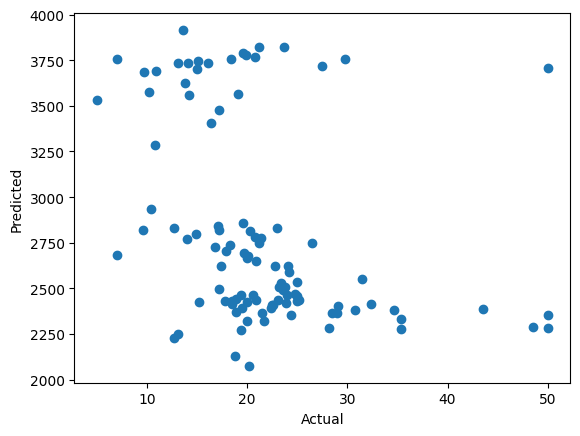

In [36]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()